In [4]:
import pandas as pd, matplotlib as mpl
mpl.rcParams['figure.figsize'] = [16, 9]

legs = [("front left", "fl"), ("front right", "fr"), ("back left", "bl"), ("back right", "br")]
joints = ["hip", "thigh", "calf"]
params = ["kp", "kd", "q", "q_r", "dq", "dq_r", "tau", "tau_est"]

In [5]:
# Load CSV dataset
df = pd.read_csv("split-slow-fw.csv")
list(df.columns)

['Unnamed: 0',
 'time',
 'fr_hip_kp',
 'fr_hip_kd',
 'fr_hip_tau',
 'fr_hip_q_r',
 'fr_hip_dq_r',
 'fr_hip_tau_est',
 'fr_hip_q',
 'fr_hip_dq',
 'fr_thigh_kp',
 'fr_thigh_kd',
 'fr_thigh_tau',
 'fr_thigh_q_r',
 'fr_thigh_dq_r',
 'fr_thigh_tau_est',
 'fr_thigh_q',
 'fr_thigh_dq',
 'fr_calf_kp',
 'fr_calf_kd',
 'fr_calf_tau',
 'fr_calf_q_r',
 'fr_calf_dq_r',
 'fr_calf_tau_est',
 'fr_calf_q',
 'fr_calf_dq',
 'fl_hip_kp',
 'fl_hip_kd',
 'fl_hip_tau',
 'fl_hip_q_r',
 'fl_hip_dq_r',
 'fl_hip_tau_est',
 'fl_hip_q',
 'fl_hip_dq',
 'fl_thigh_kp',
 'fl_thigh_kd',
 'fl_thigh_tau',
 'fl_thigh_q_r',
 'fl_thigh_dq_r',
 'fl_thigh_tau_est',
 'fl_thigh_q',
 'fl_thigh_dq',
 'fl_calf_kp',
 'fl_calf_kd',
 'fl_calf_tau',
 'fl_calf_q_r',
 'fl_calf_dq_r',
 'fl_calf_tau_est',
 'fl_calf_q',
 'fl_calf_dq',
 'br_hip_kp',
 'br_hip_kd',
 'br_hip_tau',
 'br_hip_q_r',
 'br_hip_dq_r',
 'br_hip_tau_est',
 'br_hip_q',
 'br_hip_dq',
 'br_thigh_kp',
 'br_thigh_kd',
 'br_thigh_tau',
 'br_thigh_q_r',
 'br_thigh_dq_r',
 'br

<AxesSubplot:xlabel='time'>

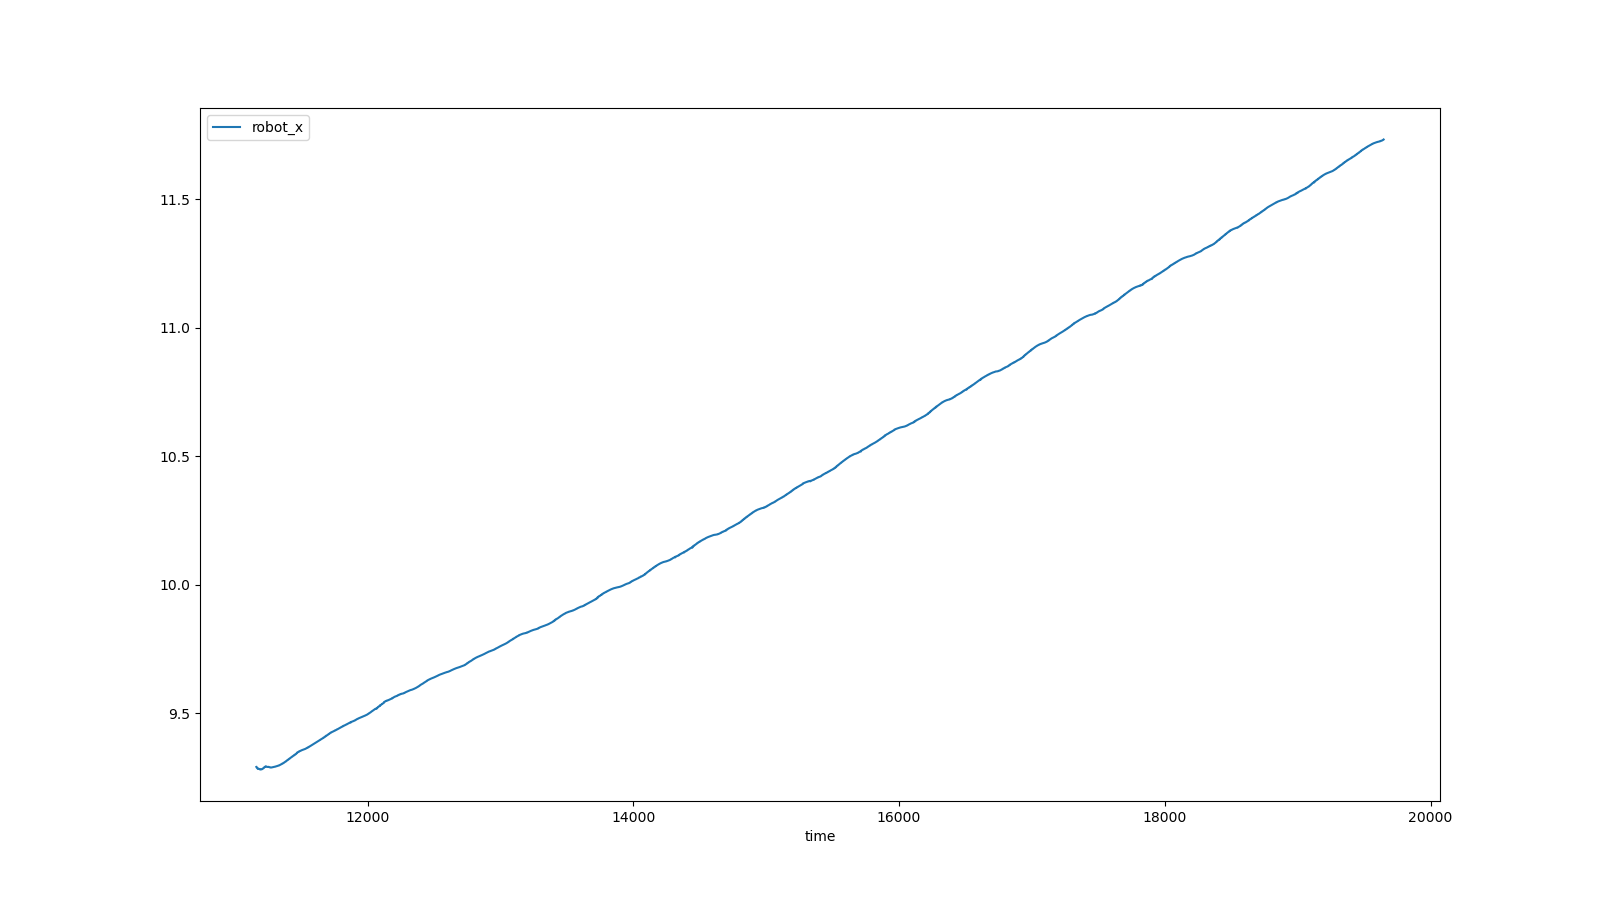

In [6]:
%matplotlib widget
df.plot(x="time", y=["robot_x"])

<AxesSubplot:xlabel='time'>

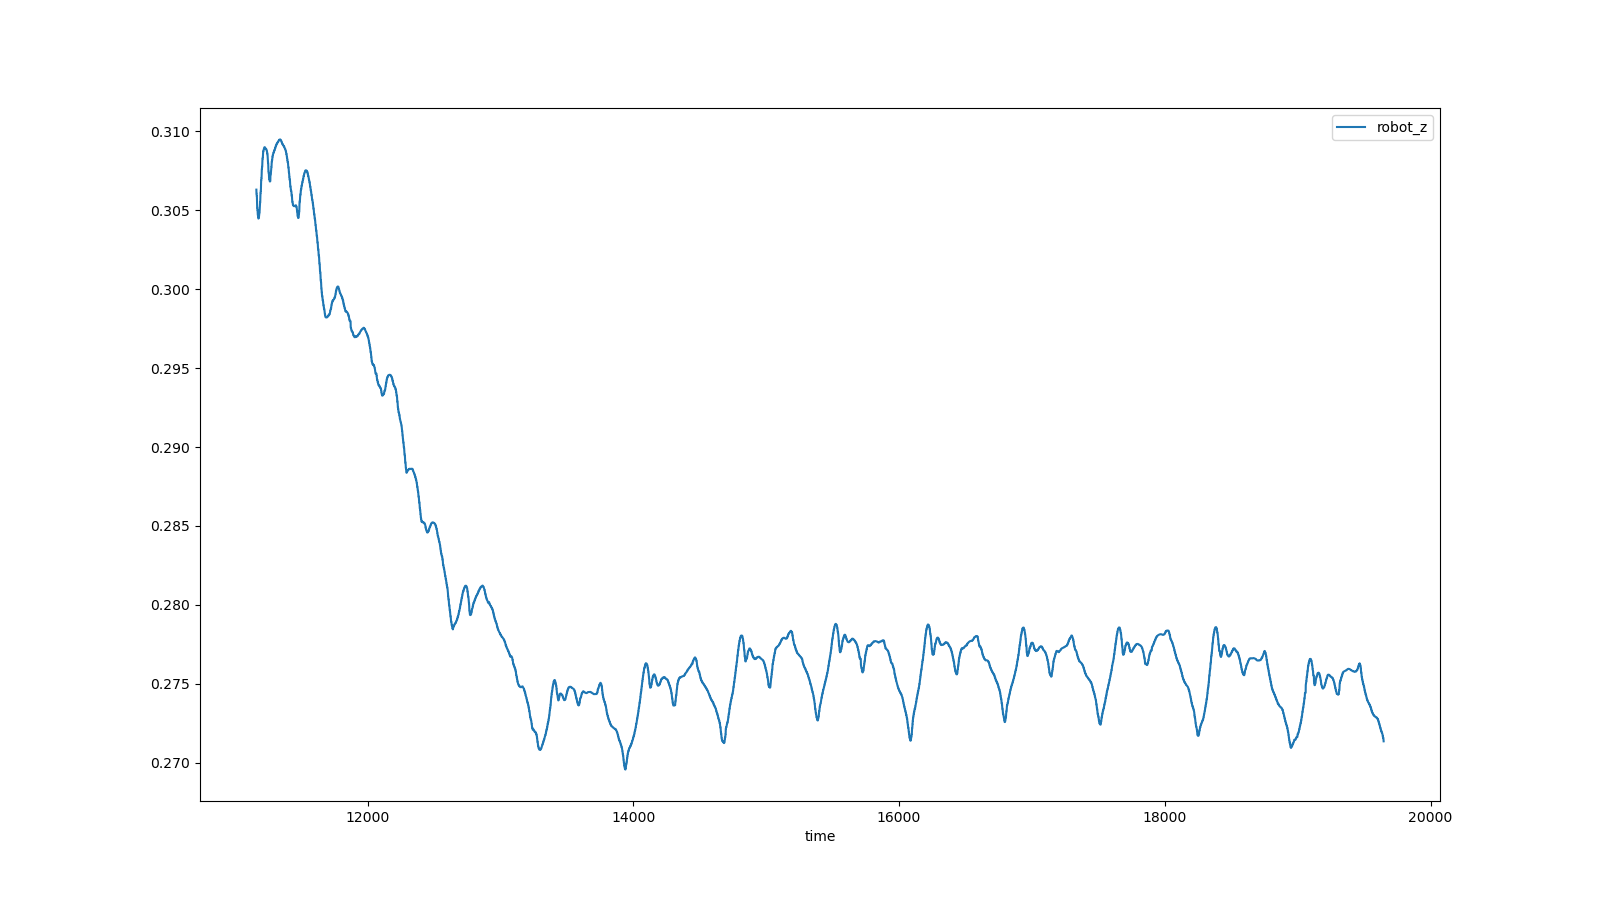

In [7]:
%matplotlib widget
df.plot(x="time", y=["robot_z"])

<AxesSubplot:xlabel='time'>

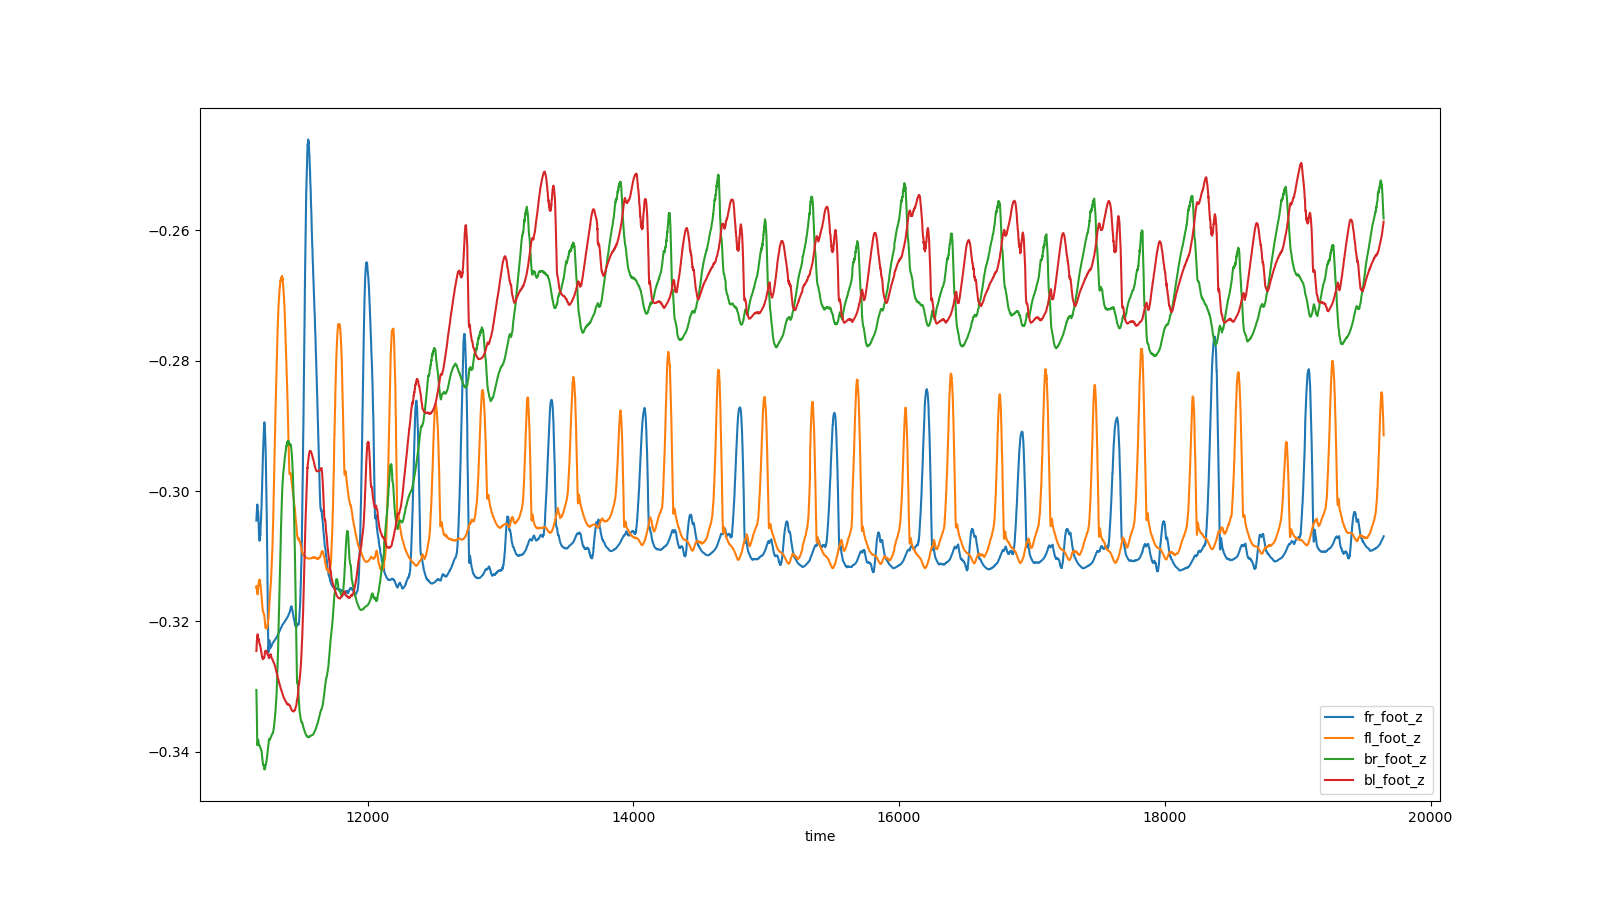

In [8]:
%matplotlib widget
df.plot(x="time", y=["fr_foot_z", "fl_foot_z", "br_foot_z", "bl_foot_z"])

<AxesSubplot:xlabel='time'>

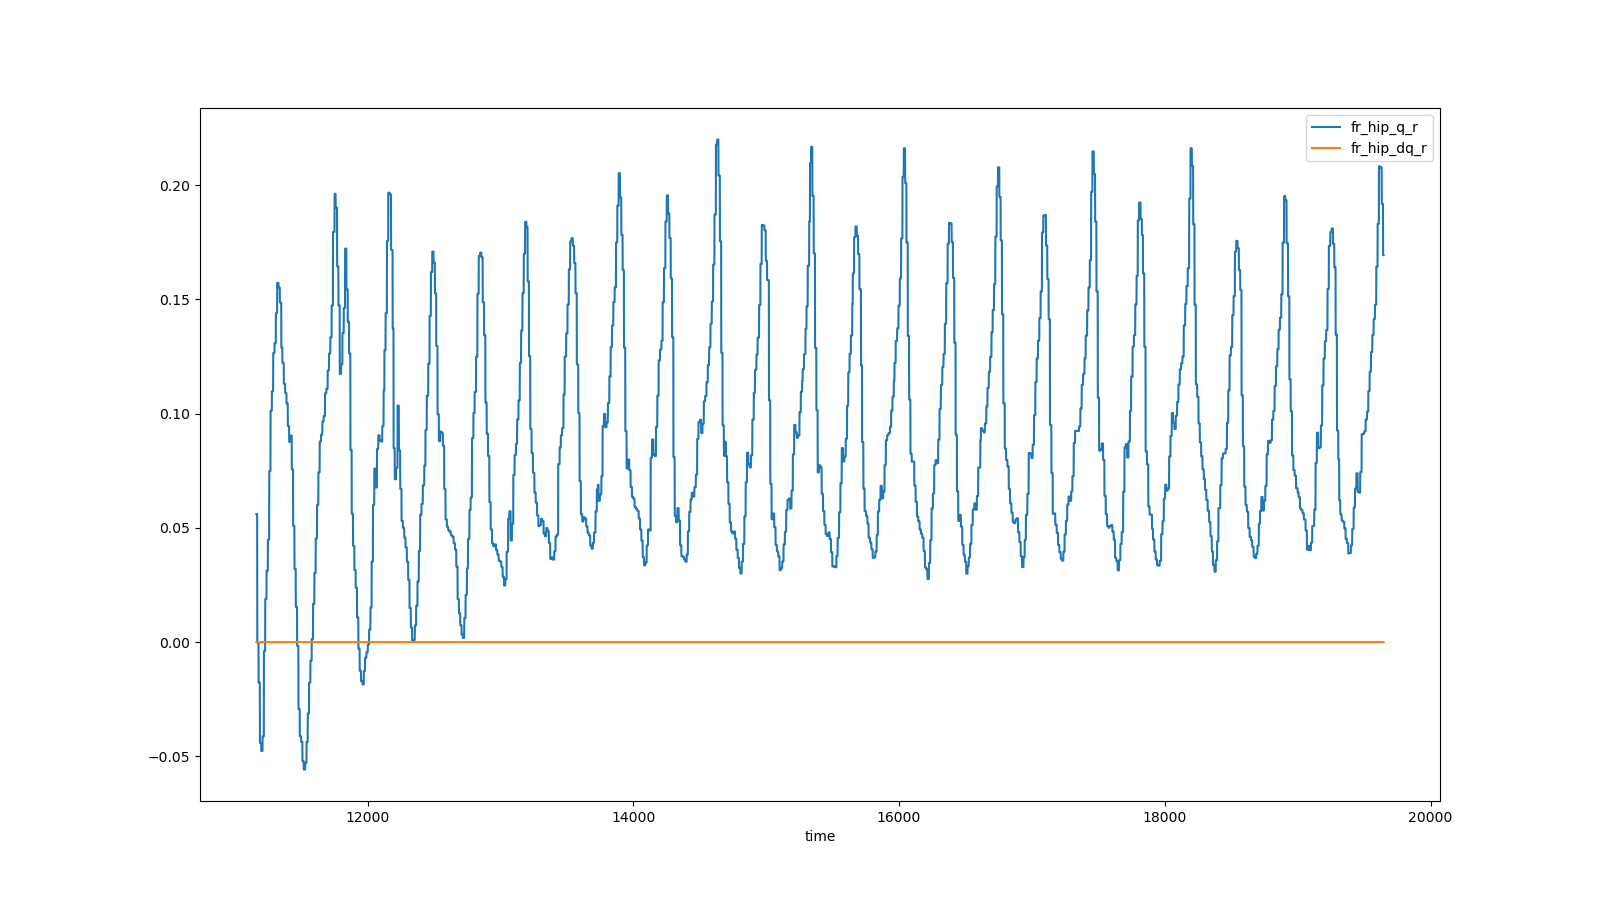

In [10]:
%matplotlib widget
df.plot(x="time", y=["fr_hip_q_r", "fr_hip_dq_r"])

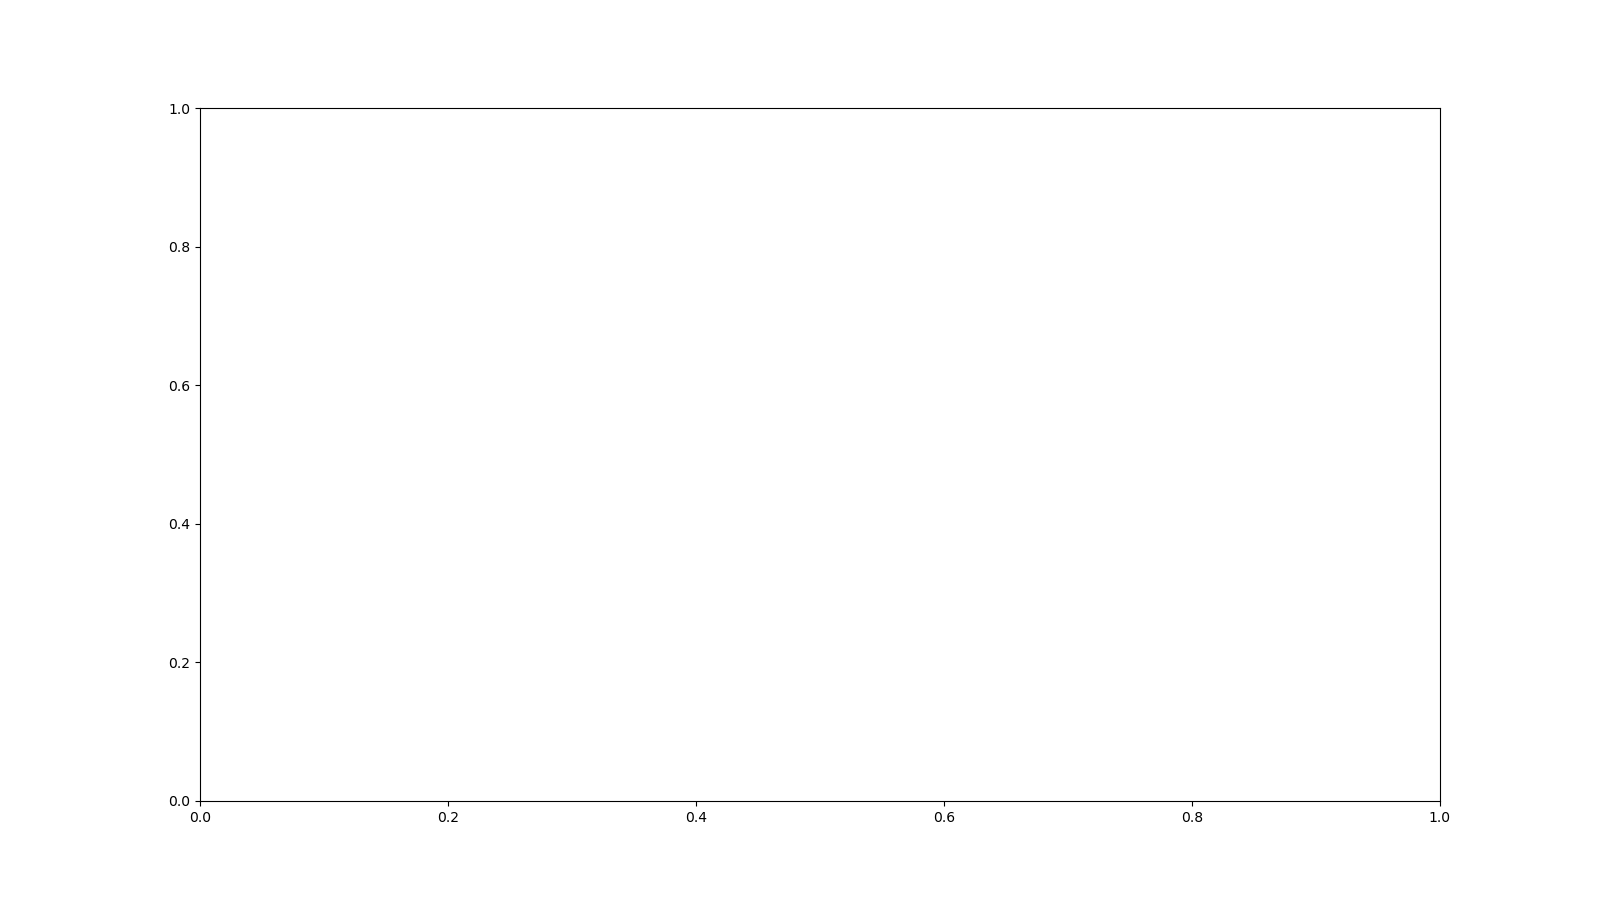

In [11]:
%matplotlib widget
import ipywidgets as widgets
import matplotlib.pyplot as plt

leg_select = widgets.Dropdown(description="Leg:", options=legs)
joint_select = widgets.Dropdown(description="Joint:", options=joints)


checkboxes = {}
checkboxes_list = []
for param in params:
    checkboxes[param] = widgets.Checkbox(description=f"{param}", value=False)
    checkboxes_list.append(checkboxes[param])

out = widgets.Output(layout={'border': '1px solid black'})

joint_axes = plt.subplot()

def update(change = None):
    with out:
        leg_sel = leg_select.value
        joint_sel = joint_select.value
        params_sel = [f"{leg_sel}_{joint_sel}_{param}" for param in params if checkboxes[param].value]

        joint_axes.clear()

        if not len(params_sel):
            return
        
        df.plot(x="time", y=params_sel, ax=joint_axes)
        # print(leg_sel, joint_sel, params_sel)

leg_select.observe(update, names="value")
joint_select.observe(update, names="value")
for cb in checkboxes_list:
    cb.observe(update, names="value")

controls_bar = widgets.HBox([leg_select, joint_select])
checkboxes_list = widgets.HBox(checkboxes_list)
surface = widgets.VBox([controls_bar, checkboxes_list, out])

surface

<AxesSubplot:xlabel='time'>

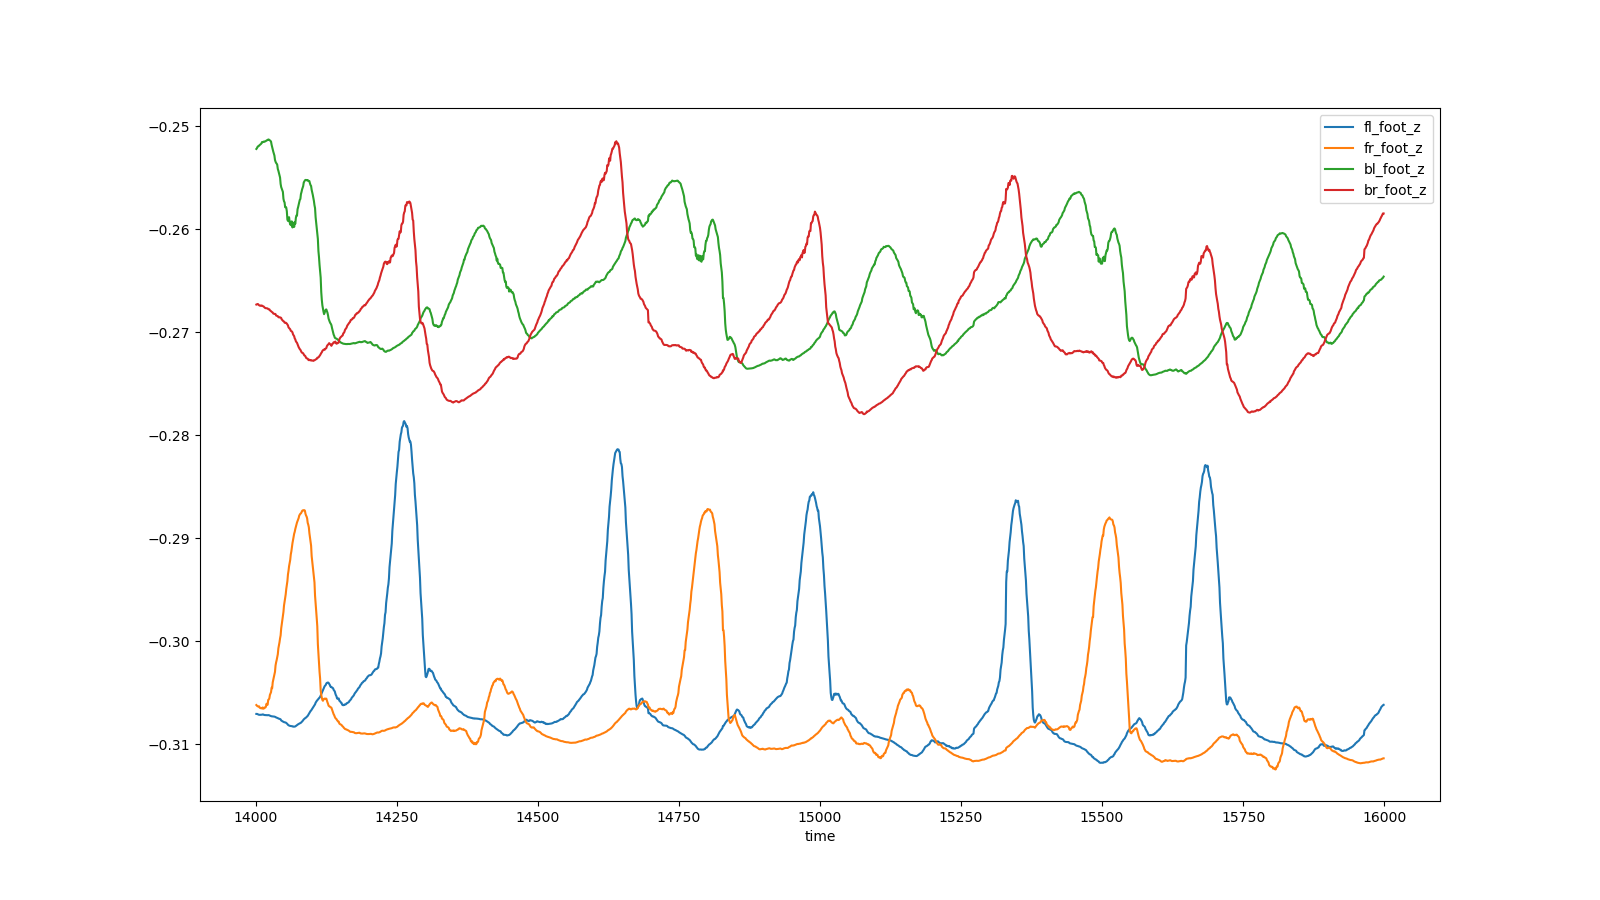

In [9]:
%matplotlib widget
lines = [f"{leg[1]}_foot_z" for leg in legs]
df[(df["time"] > 14000) & (df["time"] < 16000)].plot(x="time", y=lines)